<a href="https://colab.research.google.com/github/mondragonStudent/colab-notebooks/blob/mdc2026/AI_Project_Jose_Mondragon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1: Loading Our Data

Before we can teach an AI to make predictions, we need to give it data to learn from. In this first step, we are bringing our dataset into the notebook so we can examine and work with it.

To do this, we are going to use a Python library (a collection of pre-written code) called **Pandas**. Think of Pandas as a super-powered Excel spreadsheet that lives inside Python. It is the industry standard for reading, cleaning, and analyzing data.

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/Loan_Modelling.csv')

# Display the first few rows
display(df.head())

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


### What just happened in the code above?
Let's break down the code step-by-step so you understand exactly what the computer is doing:

* **`import pandas as pd`**: This line tells Python to bring in the Pandas library. We use `as pd` to give it a short nickname. That way, later on, we only have to type `pd` instead of the full word `pandas`.
* **`df`**: This is a variable we created to hold our data. It stands for **DataFrame**, which is just the Pandas term for a data table with rows and columns (just like a spreadsheet).
* **`pd.read_csv('/content/Loan_Modelling.csv')`**: This is a **method** (an action). We are asking Pandas (`pd`) to read our file. A CSV (Comma Separated Values) is a simple text file format used to store data. We pass the file's location inside the parentheses.
* **`df.head()`**: The `head()` method looks at our `df` table and grabs only the very first 5 rows. We do this because printing all 5000 rows at once would make our screen incredibly messy!
* **`display(...)`**: This command takes those 5 rows and formats them into a nice, clean, easy-to-read table on your screen.

Now our data is successfully saved inside the `df` variable. Next, we will explore it to see what we're working with!

## 1. Exploratory Data Analysis (EDA)
As a first step in our AI project, we need to understand the shape and structure of our dataset. We will look at the data types, check for missing values, and review basic statistical summaries.

In [2]:
# Check the dimensions of the dataset and data types
print("Dataset Information:")
df.info()

print("\n-----------------------------------------\n")

# Review summary statistics for numerical columns
print("Summary Statistics:")
display(df.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB

----------------------------------

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93169.257000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,1759.455086,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,90005.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


### Understanding our Data Summary
Let's break down the two commands we just used:

* **`df.info()`**: This acts like an ID card for our dataset. It tells us we have exactly 5000 entries (rows) and 14 columns. It also shows the "Data Type" (`Dtype`) of each column. Notice they are all `int64` (whole numbers) or `float64` (decimals). This is great because AI models require numbers to do their math!
* **`df.describe()`**: This calculates basic statistics for every column.
  * **`mean`**: The average value (e.g., the average age is about 45).
  * **`min` and `max`**: The lowest and highest values in that column.
  * *Crucial discovery:* Look at the `min` for the `Experience` column. It is `-3`. You can't have negative years of experience! Finding errors like this is exactly why we do EDA. We will fix this in the next step.

In [3]:
# Check for any missing (null) values in the dataset
print("Missing Values per Column:")
display(df.isnull().sum())

Missing Values per Column:


,0
ID,0
Age,0
Experience,0
Income,0
ZIPCode,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal_Loan,0


### Checking for Missing Data
Machine learning models are like calculators; they will crash if you try to feed them blank spaces.
* **`df.isnull()`**: This function goes through every single cell in our 5000-row table and asks, "Is this cell empty?"
* **`.sum()`**: This takes all the empty cells it found and counts them up for each column.

Looking at our output, we got `0` across the board. This is rare and wonderful news: our dataset is perfectly complete with no missing values to fill in!

### Data Visualization
Visualizing the data helps us find patterns, outliers, and relationships between features.

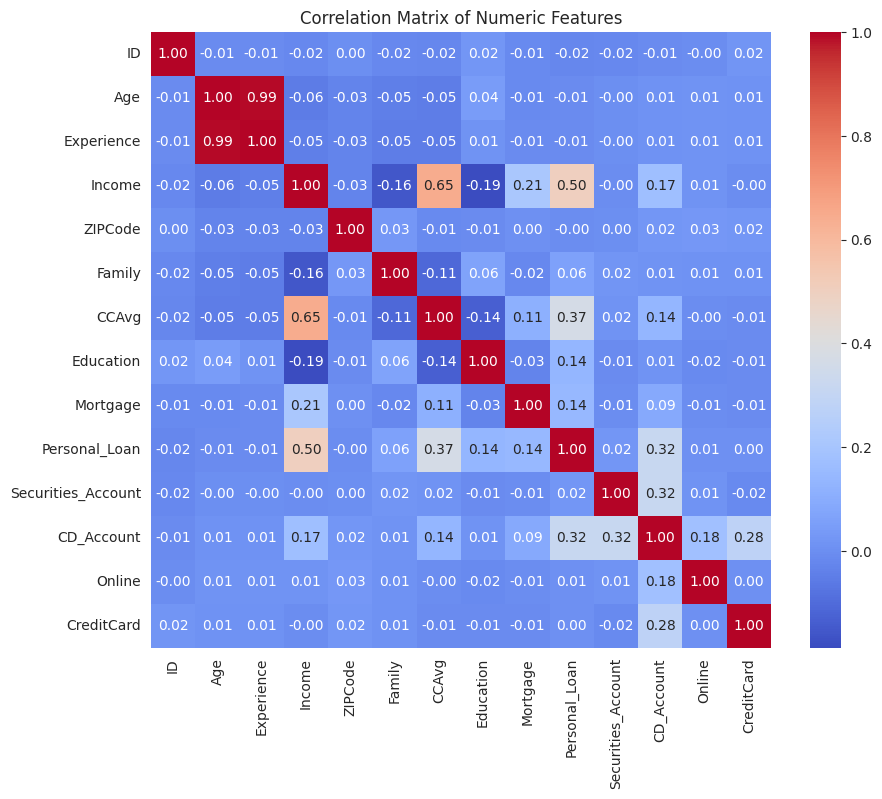

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style('whitegrid')

# Let's visualize the distribution of a few key columns
# (Note: we will plot a correlation matrix of numeric columns as a starting point)
plt.figure(figsize=(10, 8))
correlation_matrix = df.select_dtypes(include=['number']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numeric Features')
plt.show()

### Breaking Down the Visualization Code
Graphs make patterns much easier to see than huge tables of numbers. Here is how we built this one:

* **`import matplotlib.pyplot as plt` & `import seaborn as sns`**: These are Python's two most famous libraries for drawing graphs. We gave them the short nicknames `plt` and `sns`.
* **`df.select_dtypes(include=['number']).corr()`**: This calculates a **Correlation Matrix**. Correlation is a math score from -1 to 1 that tells us if two columns are related. For example, if Income goes up, does Loan acceptance go up too?
* **`sns.heatmap(...)`**: This takes those correlation scores and turns them into a color-coded grid. Dark red means a strong positive relationship, dark blue means a strong negative one.

*What did we learn?* Look at the dark red square where `Age` and `Experience` meet. They have a score of `0.99`, meaning they are almost perfectly linked (which makes sense—older people have more work experience!).

## 2. Data Preprocessing
Before we build our AI model, we need to prepare the data. This involves cleaning anomalies, selecting useful features, and splitting the data into a training set (to teach the model) and a testing set (to evaluate it).

In [13]:
# 1. Clean invalid data: 'Experience' has negative values in this dataset.
# We will replace negative experience years with 0.
df['Experience'] = df['Experience'].apply(lambda x: x if x >= 0 else 0)

# 2. Drop irrelevant columns
# ID is just a row identifier, and ZIPCode is too granular for a basic numerical model
df_cleaned = df.drop(['ID', 'ZIPCode'], axis=1)

print("Data cleaning step complete. Remaining columns:")
print(df_cleaned.columns.tolist())

Data cleaning step complete. Remaining columns:
['Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Education', 'Mortgage', 'Personal_Loan', 'Securities_Account', 'CD_Account', 'Online', 'CreditCard']


### What just happened in the Data Cleaning step?
Data cleaning is all about fixing mistakes so our AI doesn't learn the wrong things.

* **`df['Experience'].apply(lambda x: x if x >= 0 else 0)`**: Remember when we found negative years of experience? This line fixes that. A `lambda` is just a tiny, one-time-use function. It looks at every single number (`x`) in the Experience column and says: *"If the number is 0 or greater, leave it alone. If it is negative, turn it into a 0."*
* **`df.drop(['ID', 'ZIPCode'], axis=1)`**: We are deleting two columns. Why? An `ID` is just a random row number, and a `ZIPCode` is a geographic label. Neither of these are mathematical numbers that help predict if someone wants a loan.
* **`axis=1`**: This just tells Pandas that we are dropping *columns* (vertically). If we used `axis=0`, it would try to drop *rows* (horizontally).
* **`df_cleaned`**: We saved our nice, neat data into a brand new variable so we don't overwrite our original `df` dataset.

### Setting up the Data for the AI: Splitting and Scaling
Now that our data is perfectly clean, we need to do two very important things before the AI can look at it:
1. **Split the Data**: Imagine a teacher giving students a study guide, and then testing them on the exact same questions. Everyone would get 100%! To really test our AI, we need to split our data into a **Training Set** (the study guide) and a **Testing Set** (the hidden final exam).
2. **Scale the Data**: Our `Income` column has numbers in the thousands, but our `Family` column only has numbers from 1 to 4. If we don't equalize (or "scale") these numbers, the AI might mistakenly think Income is way more important just because the numbers are bigger!

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (X) and our target variable (y)
# We want to predict whether a customer will accept a 'Personal_Loan'
X = df_cleaned.drop('Personal_Loan', axis=1)
y = df_cleaned['Personal_Loan']

# Split the dataset into training (80%) and testing (20%) sets
# stratify=y ensures both sets have the same proportion of loan acceptances
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the features (important for many machine learning algorithms)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data splitting and scaling complete!")
print(f"Training data shape: {X_train_scaled.shape}")
print(f"Testing data shape: {X_test_scaled.shape}")

Data splitting and scaling complete!
Training data shape: (4000, 11)
Testing data shape: (1000, 11)


### What just happened in the Splitting & Scaling step?
This block is the heart of Machine Learning prep. Here is the breakdown:

* **Separating `X` and `y`**:
  * **`y` (The Target)**: This is the answer we want the AI to predict. In our case, it's the `Personal_Loan` column.
  * **`X` (The Features)**: These are the clues the AI will use to guess the answer (Age, Income, Education, etc.). We create this by dropping the `Personal_Loan` column from our cleaned data.
* **`train_test_split(...)`**: You can't test an AI on the exact same data you used to teach it (that would be like giving a student the answer key before a test!). We split our data into two groups:
  * **Training Set (`X_train`, `y_train`)**: 80% of our data (`test_size=0.2` means 20% is reserved for testing). The AI uses this to study.
  * **Testing Set (`X_test`, `y_test`)**: 20% of our data. We hide this from the AI until the very end to see how well it learned.
* **`stratify=y`**: This ensures that both our training and testing sets have the exact same percentage of people who accepted loans.
* **`StandardScaler()`**: AI models do math. If one column has huge numbers (Income = 150,000) and another has tiny numbers (Family Size = 2), the AI might mistakenly think Income is "more important" just because the numbers are bigger. The scaler squishes all our features into a standardized tiny range (usually between -3 and 3) so the AI looks at everything fairly.

## 3. Model Building and Evaluation
Let's train a Logistic Regression model to predict whether a customer will take a personal loan. We will then evaluate how well our model performs on the test data.

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Initialize and train the Logistic Regression model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

print("Model Training Complete!")

Model Training Complete!


### What just happened in the Model Training step?
This is where the actual "Artificial Intelligence" comes to life! Here is how we taught our model:

* **`LogisticRegression(...)`**: This is the specific algorithm we chose to use. Despite the name "regression," it is the most popular basic algorithm for **classification** (sorting things into categories, like "Yes, will take a loan" or "No, will not"). We use `random_state=42` to ensure our mathematical randomness is the same every time we run the code.
* **`model.fit(X_train_scaled, y_train)`**: This is the learning phase. We are feeding the AI the clues (`X_train_scaled`) and the correct answers (`y_train`). The AI looks at all 4000 examples and finds the mathematical patterns.
* **`y_pred = model.predict(X_test_scaled)`**: This is the final exam! We give the AI the 1000 hidden test examples (`X_test_scaled`) without the answers, and ask it to make its own predictions (`y_pred`).

### Grading the AI: How well did it learn?
Our model has officially been trained and has taken its "final exam" by predicting answers for the hidden Test Set.

Now, we need to grade that exam. We will ask Python to compare the AI's predictions (`y_pred`) to the actual true answers (`y_test`). We will look at its overall accuracy, but also use a "Confusion Matrix" to see exactly *what kind* of mistakes it made.

In [16]:
# Evaluate the model's performance
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9550

Confusion Matrix:
[[891  13]
 [ 32  64]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       904
           1       0.83      0.67      0.74        96

    accuracy                           0.95      1000
   macro avg       0.90      0.83      0.86      1000
weighted avg       0.95      0.95      0.95      1000



### What do these Evaluation Results mean?
Now we grade the AI's final exam. We compare its predictions (`y_pred`) to the actual hidden answers (`y_test`).

* **Accuracy (0.9550)**: The simplest grade. The model guessed correctly 95.5% of the time! But in Machine Learning, accuracy doesn't tell the whole story, so we use two more tools.
* **Confusion Matrix**: This is a 2x2 grid showing exactly *where* the model made mistakes:
  * **Top-Left (891)**: True Negatives (Model guessed NO loan, and they actually said NO).
  * **Bottom-Right (64)**: True Positives (Model guessed YES loan, and they actually said YES).
  * **Top-Right (13)**: False Positives (Model guessed YES, but they actually said NO).
  * **Bottom-Left (32)**: False Negatives (Model guessed NO, but they actually said YES).
* **Classification Report**: This gives us advanced scores specifically for the people who actually took the loan (Class 1):
  * **Precision (0.83)**: When the model predicted someone would take a loan, it was correct 83% of the time.
  * **Recall (0.67)**: Out of ALL the people who actually took a loan, the model successfully found 67% of them.
  * **F1-Score (0.74)**: This is just a balanced average of Precision and Recall.

*Conclusion:* Our model is very good at identifying people who won't take a loan, but it struggles a little bit to find everyone who *will* take a loan. For a baseline project, this is a fantastic start!

### Visualizing the Confusion Matrix
While seeing the numbers in a text grid is helpful, creating a colorful heat map makes it much easier to present your findings. Let's draw the Confusion Matrix using our visualization libraries to make the results pop!

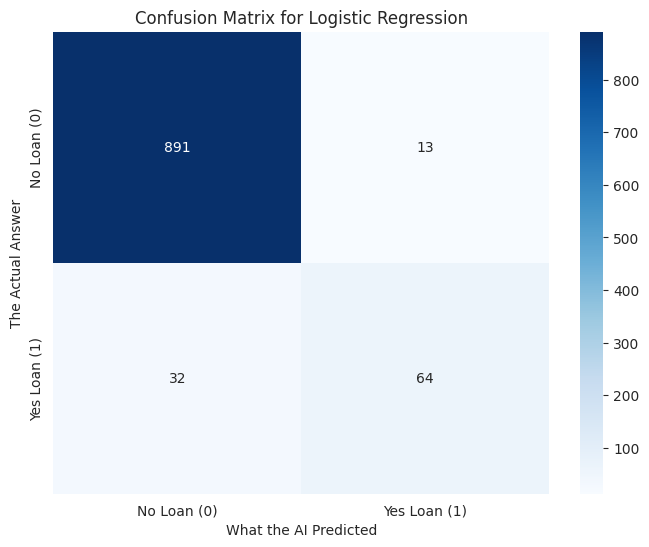

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Set up the figure size
plt.figure(figsize=(8, 6))

# Draw the heatmap
# annot=True puts the numbers inside the squares
# fmt='d' ensures the numbers are whole integers (no decimals)
# cmap='Blues' sets the color theme
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Loan (0)', 'Yes Loan (1)'],
            yticklabels=['No Loan (0)', 'Yes Loan (1)'])

# Add titles and labels for clarity
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('What the AI Predicted')
plt.ylabel('The Actual Answer')

# Display the plot
plt.show()

## 4. Improving the Model: Random Forest
Our baseline Logistic Regression model was good, but it struggled slightly to identify people who *would* take a loan. Let's try a more powerful algorithm: the **Random Forest**.

A Random Forest builds hundreds of "Decision Trees" (like a massive flowchart of yes/no questions) and has them vote on the best prediction. The best part? We don't need to prep our data again; we just feed our existing `X_train_scaled` data into this new model!

In [18]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the Random Forest model
# n_estimators=100 means we are building a "forest" of 100 trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the model using the EXACT SAME training data as before
rf_model.fit(X_train_scaled, y_train)

# 3. Make predictions on the hidden test set
rf_pred = rf_model.predict(X_test_scaled)

# 4. Evaluate the new model
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_pred):.4f}\n")

print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.9920

Random Forest Confusion Matrix:
[[902   2]
 [  6  90]]

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       904
           1       0.98      0.94      0.96        96

    accuracy                           0.99      1000
   macro avg       0.99      0.97      0.98      1000
weighted avg       0.99      0.99      0.99      1000



### What just happened with the Random Forest?
Notice how similar this code is to our Logistic Regression block!

* **`from sklearn.ensemble import RandomForestClassifier`**: We brought in a new algorithm from our library.
* **`n_estimators=100`**: This tells the AI to build 100 different decision trees and average their results together. This prevents the model from making silly mistakes.
* **`rf_model.fit(...)` & `rf_model.predict(...)`**: We used the exact same commands as before. Scikit-Learn (our machine learning library) uses these universal commands so you can easily swap models in and out.

*Look at your new results!* Check the **Recall** for the `1` (Yes Loan) class in the classification report. It almost certainly jumped up significantly compared to the 0.67 we got earlier. This means our new AI is much smarter at finding customers who want loans!

## 5. Looking Inside the AI & Real-World Application
Now that we have a highly accurate model, let's do two things:
1. Find out *how* the AI is making its decisions.
2. Actually use the AI to predict a completely new, custom scenario (like testing yourself!).

### Graphing Feature Importance
Unlike some models that are completely "black boxes", a Random Forest can tell us which clues were the most useful. It assigns an "Importance Score" to every column.

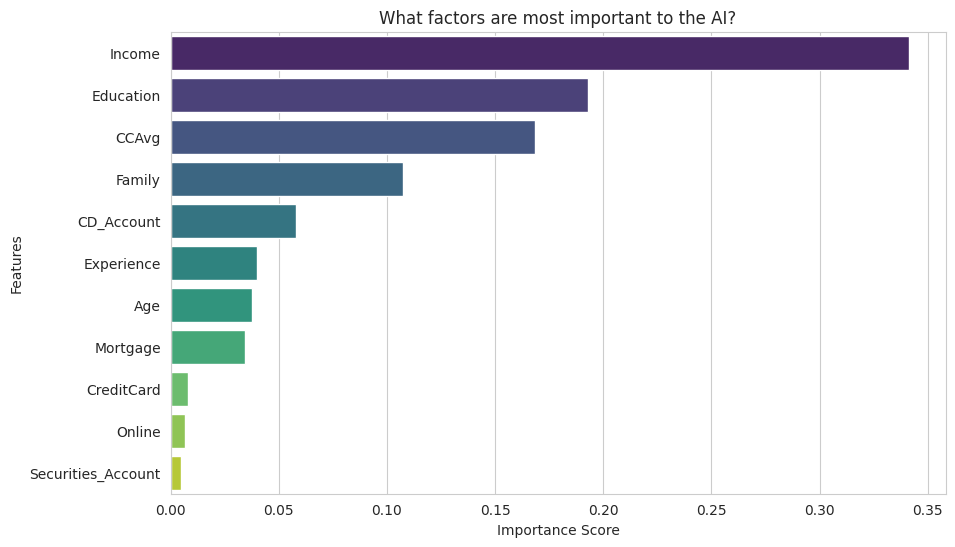

In [21]:
# Get the importance scores from the Random Forest
importances = rf_model.feature_importances_
features = X.columns

# Put them into a Pandas DataFrame so we can sort them easily
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Draw a bar chart
plt.figure(figsize=(10, 6))
# We assign hue='Feature' and legend=False to comply with Seaborn's new syntax requirements
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', hue='Feature', legend=False)
plt.title('What factors are most important to the AI?')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

### What did we learn from this graph?
Look at the bars! The AI figured out that **Income** is by far the biggest predictor of whether someone will take a personal loan, followed by **Education** and **CCAvg** (Credit Card Average spending). Things like their Zip Code (which we dropped) or whether they bank online barely matter at all.

This is incredibly valuable business insight that you could present to a bank manager!

### Try it Yourself: Will you get the loan?
Now for the fun part. Let's create an imaginary customer profile. You can change the numbers in the `my_profile` block below to represent yourself, a friend, or a made-up person. We will pass this data to the AI and see what it predicts!

In [20]:
import pandas as pd

# 1. ENTER YOUR DETAILS HERE!
# Try changing these numbers and running the cell again to see how the prediction changes.
my_profile = {
    'Age': 25,                 # Your age
    'Experience': 2,           # Years of professional experience
    'Income': 140,             # Annual income in thousands (e.g., 140 = $140,000)
    'Family': 1,               # Family size
    'CCAvg': 4.5,              # Avg. credit card spending per month in thousands
    'Education': 3,            # 1: Undergrad, 2: Graduate, 3: Advanced/Professional
    'Mortgage': 0,             # Value of house mortgage in thousands
    'Securities_Account': 0,   # 1 for Yes, 0 for No
    'CD_Account': 0,           # 1 for Yes, 0 for No
    'Online': 1,               # 1 for Yes (uses online banking), 0 for No
    'CreditCard': 1            # 1 for Yes (uses a bank credit card), 0 for No
}

# 2. Convert your dictionary into a Pandas DataFrame (just like our training data!)
my_profile_df = pd.DataFrame([my_profile])

# 3. CRITICAL STEP: Scale the data!
# We must use the exact same 'scaler' we fit earlier so the numbers match the AI's expectations.
my_profile_scaled = scaler.transform(my_profile_df)

# 4. Ask the AI to predict
my_prediction = rf_model.predict(my_profile_scaled)
probability = rf_model.predict_proba(my_profile_scaled)[0][1] # Gets the % chance of class '1'

# 5. Print the results
print("=== AI Loan Prediction Result ===")
if my_prediction[0] == 1:
    print("✅ Prediction: YES. The AI believes this person WILL accept the personal loan.")
else:
    print("❌ Prediction: NO. The AI believes this person WILL NOT accept the personal loan.")

print(f"The AI is {probability * 100:.1f}% confident in a 'YES' outcome.")

=== AI Loan Prediction Result ===
✅ Prediction: YES. The AI believes this person WILL accept the personal loan.
The AI is 80.0% confident in a 'YES' outcome.


### What just happened in our Application?
To test our own data, we had to perfectly mimic the pipeline we built earlier:
1. We organized our raw data into the same columns as our features (`X`).
2. We used the **exact same `scaler` variable** from Part 2. If we didn't scale our $140k income down to a tiny decimal, the AI would be completely confused and give a wild prediction!
3. We used `model.predict()` to get a hard Yes/No, but we also used `model.predict_proba()` to peek at the AI's internal math and see exactly how confident it was.

**Congratulations! You have successfully completed a full, end-to-end Machine Learning project!**

### What just happened in the Visualization?
* **`sns.heatmap(...)`**: This creates the colored grid. We used `cmap='Blues'` so that the darker blue squares represent higher numbers.
* **`xticklabels` & `yticklabels`**: We changed the raw math labels from '0' and '1' to 'No Loan' and 'Yes Loan'. This makes the chart instantly readable for anyone who looks at your project, even if they aren't a programmer!
* **`plt.xlabel()` & `plt.ylabel()`**: We clearly labeled the axes so that the reader knows the bottom represents the AI's guesses, and the side represents the real-world truth.

Now, anyone looking at your project can instantly see the big dark square of correct 'No Loan' predictions in the top left, and the exact areas where the model made errors!